# EUR/USD Buy-and-Hold Strategy Analysis

A **buy-and-hold strategy** is a passive benchmark strategy: we buy once, hold the asset over time, and measure the total performance.

In this notebook, we apply that idea to the EUR/USD exchange rate. The goal is to load historical EUR/USD data, calculate daily log returns, compute cumulative performance, and create a normalized investment-value chart starting from `1.0` USD.

This benchmark is useful because it gives us a simple reference point before testing more advanced trading strategies, risk metrics, or drawdown analysis.

## 1. Imports

We use `pandas` for time series handling, `numpy` for log-return calculations, and `matplotlib` for charts.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')

## 2. Load and Inspect the Data

The expected file is `eurusd.csv` in the same folder as this notebook. It should contain one date column and one EUR/USD price column.

If the CSV is not available, this notebook creates a small reproducible synthetic EUR/USD-style dataset so the analysis can still run from top to bottom.

In [2]:
def create_synthetic_eurusd_data(seed=7):
    """Create reproducible EUR/USD-like daily data when eurusd.csv is unavailable."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start='2018-01-02', end='2024-12-31')

    # FX daily changes are usually small, so we use modest volatility.
    synthetic_log_returns = rng.normal(loc=0.00001, scale=0.004, size=len(dates))
    synthetic_price = 1.1800 * np.exp(np.cumsum(synthetic_log_returns))

    data = pd.DataFrame({'EURUSD': synthetic_price}, index=dates)
    data.index.name = 'Date'
    return data, 'Synthetic EUR/USD data'


def find_date_column(dataframe):
    """Find a likely date column using common names first, then parsability."""
    common_date_columns = ['Date', 'Datetime', 'DateTime', 'Timestamp', 'time', 'Time']

    for column in common_date_columns:
        if column in dataframe.columns:
            return column

    for column in dataframe.columns:
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            continue

        parsed_dates = pd.to_datetime(dataframe[column], errors='coerce')
        if parsed_dates.notna().mean() > 0.80:
            return column

    raise ValueError('Could not identify a date column in eurusd.csv.')


def load_eurusd_data(filename='eurusd.csv'):
    """Load EUR/USD data from CSV, with a synthetic fallback if the file is missing."""
    candidate_paths = [Path(filename), Path('testing-strategies') / filename]
    csv_path = next((path for path in candidate_paths if path.exists()), None)

    if csv_path is None:
        return create_synthetic_eurusd_data()

    raw_data = pd.read_csv(csv_path)
    date_column = find_date_column(raw_data)

    raw_data[date_column] = pd.to_datetime(raw_data[date_column], errors='coerce')
    data = raw_data.dropna(subset=[date_column]).set_index(date_column).sort_index()
    data.index.name = 'Date'

    # Convert all non-date columns to numeric, then keep the first numeric price column.
    for column in data.columns:
        data[column] = pd.to_numeric(data[column], errors='coerce')

    numeric_columns = data.select_dtypes(include='number').columns.tolist()

    if len(numeric_columns) == 0:
        raise ValueError('No numeric EUR/USD price column found in eurusd.csv.')

    price_column = numeric_columns[0]
    data = data[[price_column]].rename(columns={price_column: 'EURUSD'}).dropna()

    return data, f'Loaded from {csv_path}'


eurusd_data, data_source = load_eurusd_data('eurusd.csv')

print(f'Data source: {data_source}')
eurusd_data.head()

Data source: Synthetic EUR/USD data


,EURUSD
Date,
2018-01-02,1.180018
2018-01-03,1.181440
2018-01-04,1.180157
2018-01-05,1.175972
2018-01-08,1.173847


We inspect the dataset before doing any calculations. This helps confirm the dates were parsed correctly, the index is a `DatetimeIndex`, and the EUR/USD column is numeric.

In [3]:
eurusd_data.head()

,EURUSD
Date,
2018-01-02,1.180018
2018-01-03,1.181440
2018-01-04,1.180157
2018-01-05,1.175972
2018-01-08,1.173847


In [4]:
eurusd_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1826 entries, 2018-01-02 to 2024-12-31
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EURUSD  1826 non-null   float64
dtypes: float64(1)
memory usage: 28.5 KB


In [5]:
print(f'Date range: {eurusd_data.index.min().date()} to {eurusd_data.index.max().date()}')
print(f'Number of observations: {len(eurusd_data):,}')
print(f'Index type: {type(eurusd_data.index)}')

Date range: 2018-01-02 to 2024-12-31
Number of observations: 1,826
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


The chart below shows the EUR/USD exchange rate over time. Before calculating returns, it is useful to visually inspect the price series for broad trends, ranges, or unusual jumps.

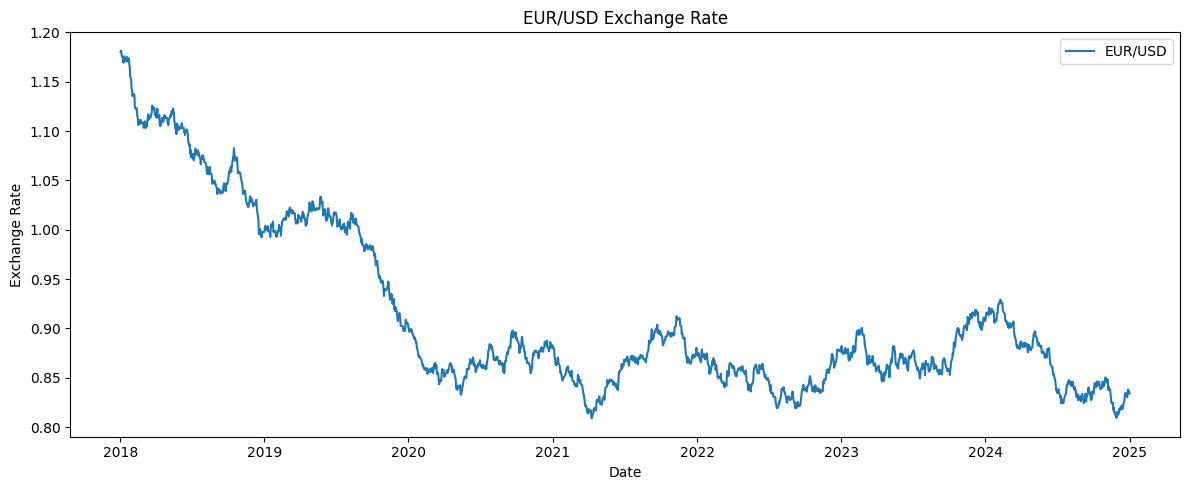

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(eurusd_data.index, eurusd_data['EURUSD'], label='EUR/USD')
plt.title('EUR/USD Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Calculate Daily Log Returns

A daily log return measures the change from one price to the next available price:

`log_return = log(price_t / price_t-1)`

The first return will be missing because the first row has no previous price to compare with.

In [ ]:
eurusd_data['log_return'] = np.log(eurusd_data['EURUSD'] / eurusd_data['EURUSD'].shift(1))

# Drop the first missing return so performance calculations are clean.
eurusd_returns = eurusd_data.dropna(subset=['log_return']).copy()

eurusd_returns.head()

## 4. Visualize Daily Returns

Daily returns show how much the exchange rate changed from one trading day to the next. FX daily returns are usually small, but they can still vary meaningfully through time.

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(eurusd_returns.index, eurusd_returns['log_return'], label='Daily log return')
plt.axhline(0, linewidth=1)
plt.title('EUR/USD Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(eurusd_returns['log_return'], bins=50)
plt.title('Histogram of EUR/USD Daily Log Returns')
plt.xlabel('Daily Log Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 5. Compute Cumulative Performance

Log returns are convenient because they are additive over time. To find the total cumulative log return, we sum the daily log returns.

To convert that cumulative log return into a final investment value, we use `np.exp()`.

In [ ]:
initial_investment = 1.0

cumulative_log_return = eurusd_returns['log_return'].sum()
final_investment_value = initial_investment * np.exp(cumulative_log_return)

print(f'Cumulative log return: {cumulative_log_return:.6f}')
print(f'Initial investment:    ${initial_investment:.2f}')
print(f'Ending value:          ${final_investment_value:.6f}')

## 6. Verify with the Price Ratio

For a buy-and-hold position, the final normalized value should match:

`final_price / initial_price`

This is a useful sanity check that our cumulative log-return calculation is correct.

In [ ]:
initial_price = eurusd_data['EURUSD'].iloc[0]
final_price = eurusd_data['EURUSD'].iloc[-1]
price_ratio = final_price / initial_price

print(f'Initial EUR/USD price: {initial_price:.6f}')
print(f'Final EUR/USD price:   {final_price:.6f}')
print(f'Final / Initial price: {price_ratio:.6f}')
print(f'Value from log returns: {final_investment_value:.6f}')
print(f'Difference:            {abs(price_ratio - final_investment_value):.12f}')

## 7. Build the Cumulative Investment Series

Now we build the full investment-value path over time.

The chart should start at `1.0`, meaning we normalize the starting investment to one dollar. Each later value shows how that passive buy-and-hold investment evolved.

In [ ]:
# Fill the first missing return with 0 so the investment series starts at 1.0.
eurusd_data['cum_log_return'] = eurusd_data['log_return'].fillna(0).cumsum()
eurusd_data['investment_value'] = initial_investment * np.exp(eurusd_data['cum_log_return'])

print('First rows:')
print(eurusd_data.head())

print('\nLast rows:')
print(eurusd_data.tail())

## 8. Plot Cumulative Investment Value

This is the normalized performance chart for the buy-and-hold strategy. It starts at `1.0` and moves with the EUR/USD exchange rate over time.

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(eurusd_data.index, eurusd_data['investment_value'], label='Buy-and-Hold Investment Value')
plt.title('EUR/USD Buy-and-Hold: Growth of $1')
plt.xlabel('Date')
plt.ylabel('Investment Value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- A buy-and-hold strategy means buying once and holding through the full sample period.
- Log returns are useful because they add cleanly over time.
- The cumulative log return can be converted into a final investment value with `np.exp()`.
- The final value from cumulative log returns should match the simple price ratio: `final_price / initial_price`.
- The cumulative investment-value chart gives a normalized view of passive EUR/USD performance starting from `1.0`.
- This buy-and-hold result is a benchmark before evaluating deeper metrics like volatility, drawdown, risk-adjusted return, or active trading strategy performance.